In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv('../data/kenya.csv', encoding='latin1')
print(df.shape)
df.head()

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [4]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16
4107,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40


Adding the country column

In [5]:
df["COUNTRY"] = "Kenya"
col = df.pop('COUNTRY')
df.insert(0, "COUNTRY", col)

Inserting a date column that converts, YEAR and DOY to a readable format

In [6]:
df['DATE'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format='%Y%j')

# saw this is another way to do it
# df['date'] = pd.to_datetime(df['YEAR'].astype(str) + df["DOY"].astype(str).str.zfill(3), format='%Y%j')

Inserting month column for seasonal analysis

In [7]:
df["MONTH"] = df["DATE"].dt.month

Removing nasa's sentinel -999 with nan values

In [8]:
df = df.replace(-999, np.nan)

Counting duplicated rows

In [9]:
df.duplicated().sum()

0

Dropping duplicated rows

In [10]:
df = df.drop_duplicates()

#### Statistical summary

In [11]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


#### Calculating percentages of missing values in each column

In [12]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct

COUNTRY        0.0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
MONTH          0.0
dtype: float64

#### Calculating Z-score

In [13]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

In [14]:
from scipy.stats import zscore

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3).sum()
outliers

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

In [15]:
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]
len(outlier_rows)

121

#### Outlier Handling Decision

Retained outliers instead of removing them, The reason for this is that theu likely represent real extreme events (e.g., heatwaves, heavy rainfall)
Important for capturing climate variability and trends and invalid values (e.g., -999 sentinel values), were already removed earlier.

If there had been values that were impossible, like a Daily Temperature High of 200 degrees celcius, these whould have been removed. But I did not see such values.

#### Handling Missing Values by filling with previous value

In [16]:
df = df.fillna(method="ffill")

C:\Users\Liya Daniel\AppData\Local\Temp\ipykernel_1360\567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Another approch to handle missing values, where missing values is greater than 30%

In [17]:
df = df.dropna(thresh=int(len(df.columns) * 0.7))

#### Exporting the dataframe 

In [18]:
df.to_csv("../data/kenya_clean.csv", index=False)

## Time Series Analysis

#### Monthly average temperature

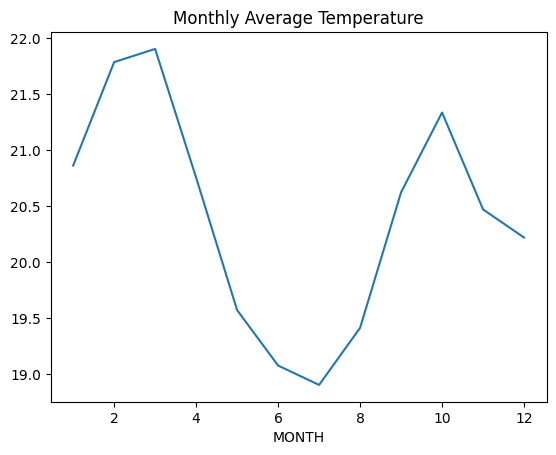

In [32]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

#### Box plot of Raninfall (prectotcorr)

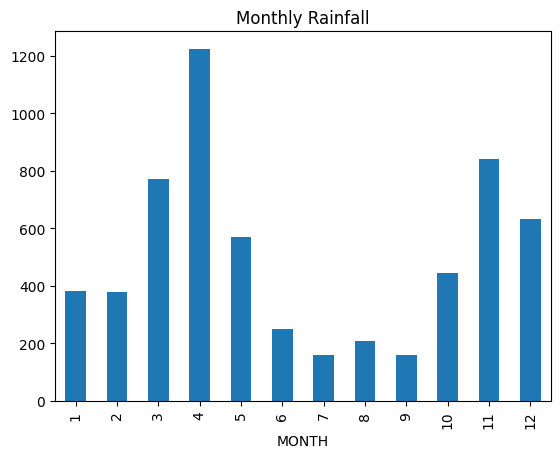

In [33]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

### Time Series Insights (Temperature & Rainfall)
The warmest months are February to March (Month 2–3), based on the highest average T2M values.  
These months show peak temperatures early in the year, followed by a second smaller peak in November.

The coolest period occurs between June and August (Month 6–8), with the lowest average temperature recorded in July.

The peak rainy season occurs in April (Month 4) with the highest rainfall, followed by a second major peak in November (Month 11). Indicating a bimodal rainfall pattern with two distinct wet seasons.

Data shows a clear seasonal cycle, with hot and relatively drier conditions early in the year, cooler mid-year, and a second wet period toward the end of the year.

## Correlation and Relationship Analysis

#### Heatmap of correlations across all numeric columns

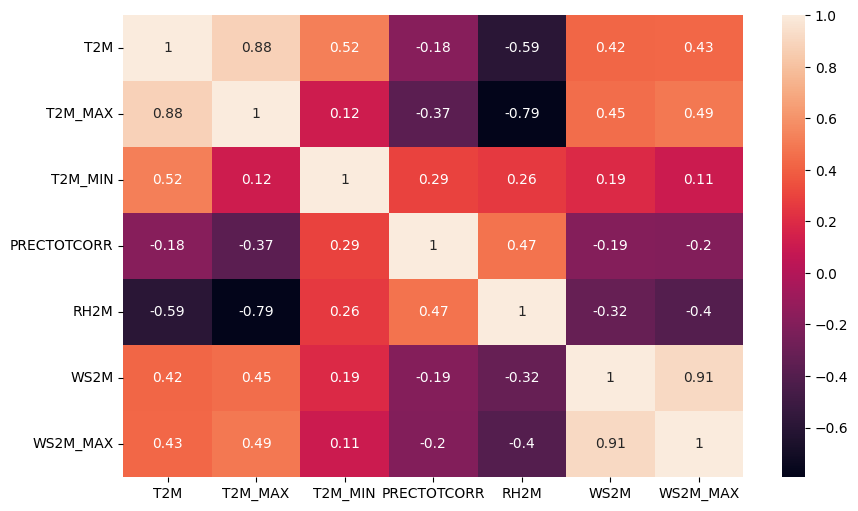

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True)
plt.show()

#### Scatter Plot (Mean Temperatue vs Relative Humidity)

<Axes: xlabel='T2M', ylabel='RH2M'>

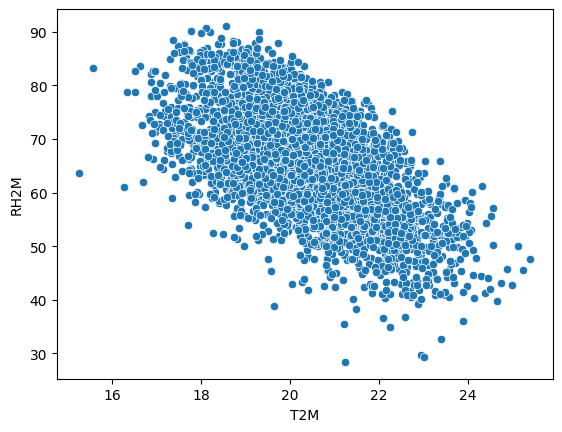

In [35]:
sns.scatterplot(data=df, x="T2M", y="RH2M")

#### Scatter Plot (Temperature range vs Windspeed)

<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

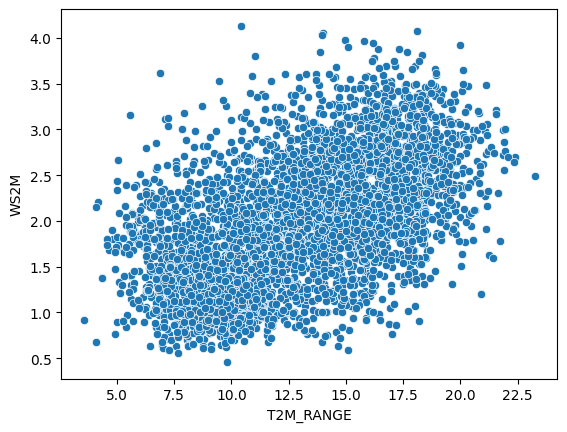

In [54]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

### Scatter Plot Insights (Mean Temperature vs Relative Humidity)
- Strong positive relationship observed between 2-meter temperature (T2M) and relative humidity (RH2M).
- As temperature increases, relative humidity tends to rise.
- Highest density of points lies between T2M 18–23°C and RH2M 50–85%.
- Data forms a dense upward-sloping cloud, indicating warmer conditions are generally more humid.

### Scatter Plot Insights (Temperature Rnge vs Wind Speed)
- Moderate positive relationship observed between 2-meter temperature (T2M_RANGE) and wind speed (WS2M).
- Wind speed tends to increase slightly as temperature rises.
- Highest density of points lies between T2M 12–20°C and WS2M 1.5–3.5 m/s.
- Data shows a broad elliptical cloud with considerable variability at all temperature levels.

## Distribution Analysis

#### Histogram of Prectotcorr

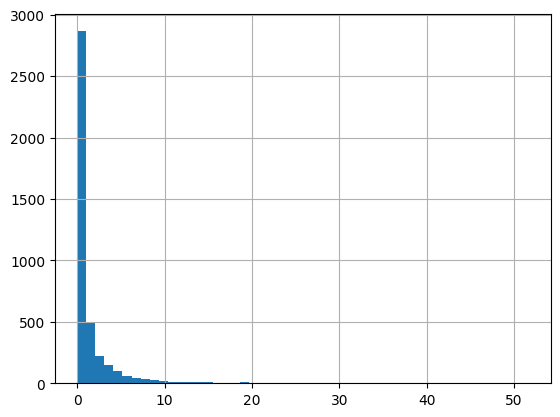

In [38]:
df["PRECTOTCORR"].hist(bins=50)
plt.show()

Highly right-skewed distribution of daily precipitation (PRECTOTCORR).
Vast majority of days have very low or zero rainfall, with a tall peak near 0 mm.

Rainfall amounts drop sharply after 5–10 mm, with very few days exceeding 20 mm.
Indicating a strong pattern of mostly dry days, interrupted by occasional moderate to heavy rain events.

#### Bubble Plot of Mean Temperature vs Relative Humidity and the size representing prectotcorr

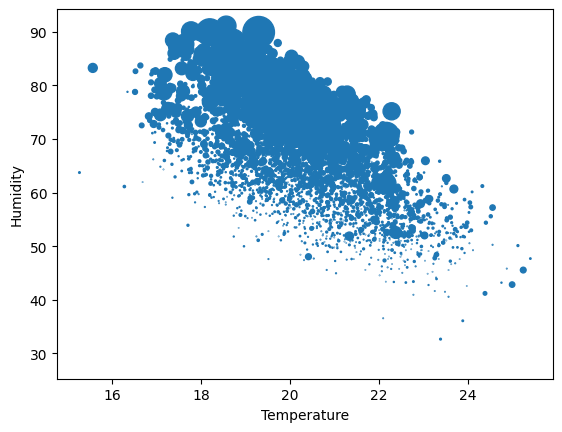

In [36]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

Shows a strong positive relationship between temperature and relative humidity in Kenya, with larger bubbles (indicating heavier rainfall) mostly clustered at higher humidity levels (70–90%).
Heavier precipitation events tend to occur when both temperature and humidity are elevated.